In [2]:
import jnp

# ==========================================
# NORMALIZATION & PHYSICS PARAMETERS BLOCK
# ==========================================
# Using normalized units where:
# distance ~ Debye length (lambda_D)
# velocity ~ Thermal velocity (v_th)
# time ~ Inverse plasma frequency (1 / omega_pe)

q = -1.0        # Normalized charge
m = 1.0         # Normalized mass
epsilon_0 = 1.0 # Normalized permittivity 

### 
def get_pe(n_e):
    ## get plasma frequence
    return jnp.sqrt(n_e * q**2 / (epsilon_0 * m))

def get_vt(T_e):
    ## get thermal velocity
    return jnp.sqrt(T_e / m)

def get_debye(T_e, n_e):
    ## get debye length
    return jnp.sqrt(epsilon_0 * T_e / (n_e * q**2)) 


In [3]:
#### SETTING for SHOCK

### transform from SI to Afven Units

import numpy as np


### Consts
mu_0 = 4 * np.pi*1e-7 ### magnetic permeability
epsilon_0 = 8.85e-12     ## electric permittivity of vacuum
mass_electron = 1e-31
mass_ion = 1836 * mass_electron
c_light = 299e+6 ## speed of light
e_charge = 1.67e-19
k_boltzman = 1.38e-23##


## Upstream
B_up_si = np.array([3.54, 0 ,3.54] ) * 1e-9 ## nT
n_up_si = 1e+6 ## m^-3 ## let it be n0
V_up_si = np.array([ -550.0, 0 , 550 ] )*1e+3 ## m/s
T_up_si = 5e+5 ### Kelvin


### Normalization (on Upstream values)
B0 =  np.sqrt(np.sum(B_up_si **2, axis = 0)) ### let it be B0
n0 = n_up_si
Va = B0/np.sqrt(mu_0 * n0 * mass_ion)
Ea =  n0 * mass_ion * Va**2
T0 = Ea / (n0 * k_boltzman)

omega_pi = np.sqrt(  n0 * e_charge**2 / (epsilon_0 * mass_ion) ) / (np.pi)
di = c_light / omega_pi
omega_ci = e_charge * B0 / mass_ion


## Downstream
B_down_si = np.array([3.54, 0 ,12.8] ) * 1e-9 ## nT
n_down_si = 3.44e+6 ## m^-3 ## let it be n0
V_down_si = np.array([ -160.0, 0 , -578 ] ) * 1e-9 ## nT
T_down_si = 6.44e+6 ### Kelvin



####### 
####### Normalized Values
#######

B_up = B_up_si / B0
n_up = n_up_si / n0
V_up = V_up_si / Va
T_up = T_up_si / T0

B_down = B_down_si / B0
n_down = n_down_si / n0
V_down = V_down_si / Va
T_down = T_down_si / T0


print('UPSTREAM VALUES:')
print('B:',B_up)
print('n:',n_up)
print('V:',V_up)
print('T:',T_up)

print('DOWNSTREAM VALUES:')
print('B:',B_down)
print('n:',n_down)
print('V:',V_down)
print('T:',T_down)



###### RESOLUTION ######

dx_si = 200e+3 
dx = dx_si / di

print('RESOLUTION:')

print('di [m] :', di)
print('dx [ in di ]  :', dx )

width = 1e+6/di
print('width [in di]: ', width)

dv_si = 30e+3
dv = dv_si / Va
print('dv :', dv)



    



UPSTREAM VALUES:
B: [0.70710678 0.         0.70710678]
n: 1.0
V: [-1.66872856  0.          1.66872856]
T: 0.3459572490307633
DOWNSTREAM VALUES:
B: [0.70710678 0.         2.55677028]
n: 3.44
V: [-4.85448310e-13  0.00000000e+00 -1.75368202e-12]
T: 4.455929367516232
RESOLUTION:
di [m] : 226731.86671837585
dx [ in di ]  : 0.8820992077325436
width [in di]:  4.410496038662718
dv : 0.09102155806901258


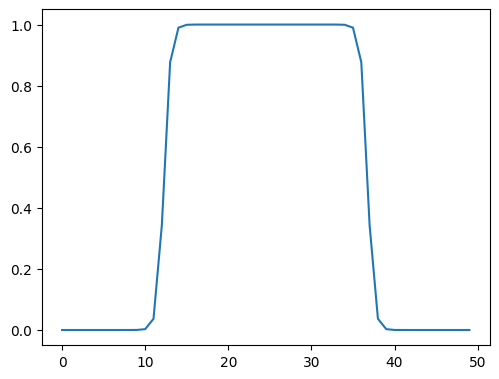

In [14]:
### PROFILE check
import matplotlib.pyplot as plt
import jax.numpy as jnp

lx = 64
x_1d = jnp.linspace(0,64)

width = 1.0 
step1 = 0.5 * (1.0 + jnp.tanh((x_1d - lx / 4) / width))
step2 = 0.5 * (1.0 - jnp.tanh((x_1d - 3 * lx / 4) / width))
S = step1 * step2 
#S_3d = 0.5 * (1.0 + jnp.tanh((X - lx / 4) / width)) * 0.5 * (1.0 - jnp.tanh((X - 3 * lx / 4) / width))

## plot
fig = plt.figure()
ax = fig.add_axes([0.1, 0.1, 0.7, 0.7])
ax.plot(S)